# Project Checkpoint 1: Dataset Selection and Exploratory Data Analysis
**Course:** CSCE 676: Data Mining & Analysis \
**Topic:** Analyzing Consumer Sentiment and Product Associations

## Project Overview
This notebook documents the selection of a dataset for the semester-long data mining project. It includes an evaluation of three candidate datasets, a comparative analysis, and initial exploratory data analysis (EDA) on the chosen dataset.

## (A) Identification of Candidate Datasets

### 1. 20 Newsgroups Dataset (Selected)
*   **Source:** Scikit-Learn Built-in Library
*   **Course Topic Alignment:** Text Mining (TF-IDF, Feature Extraction), Clustering (K-Means).
*   **Potential Beyond-Course Techniques:** **Latent Dirichlet Allocation (LDA)** for Topic Modeling and **Word2Vec** for semantic embeddings.
*   **Dataset Size and Structure:** ~18,846 newsgroup posts across 20 topics.
*   **Data Types:** Raw Text (String), Topic Label (Integer).
*   **Target Variables:** Newsgroup Category (e.g., 'sci.space', 'rec.sport.hockey').
*   **Licensing:** Public Domain / Open Access.

### 2. Online Retail Transaction Logs
*   **Source:** [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Online+Retail)
*   **Course Topic Alignment:** Frequent Itemsets and Association Rule Mining (Apriori, FP-Growth).
*   **Potential Beyond-Course Techniques:** **Sequential Pattern Mining (PrefixSpan)** to analyze the temporal order of customer purchases.
*   **Dataset Size and Structure:** 541,909 transactions (CSV).
*   **Data Types:** InvoiceNo (ID), StockCode (String), Quantity (Int), CustomerID (Float).
*   **Target Variables:** None (Unsupervised pattern mining).
*   **Licensing:** CC BY 4.0.

### 3. Twitch Social Network Graph
*   **Source:** [SNAP Social Computing Data](https://snap.stanford.edu/data/twitch_gamers.html)
*   **Course Topic Alignment:** Graph Mining (PageRank, Community Detection, Centrality).
*   **Potential Beyond-Course Techniques:** **Link Prediction** using Graph Neural Networks (GNNs).
*   **Dataset Size and Structure:** 168k nodes, 6.7M edges (Adjacency List).
*   **Data Types:** Node IDs (Int), Binary flags (Mature content), Views (Int).
*   **Target Variables:** Mature Content Flag (Binary).
*   **Licensing:** Public Domain.

## (B) Comparative Analysis of Datasets

| Dimension | 20 Newsgroups (Text) | Online Retail (Logs) | Twitch Graph (Network) |
| :--- | :--- | :--- | :--- |
| **Data Mining Tasks** | **Course:** Text Mining, Clustering. <br>**External:** LDA Topics. | **Course:** Association Rules. <br>**External:** Seq. Patterns. | **Course:** Centrality, Community. <br>**External:** Node Embeddings. |
| **Data Quality Issues** | Noisy text (ASCII art, old headers), empty posts. | High sparsity (most items rarely bought together), missing Customer IDs. | High skewness; celebrity streamers create "super-nodes" that bias metrics. |
| **Algorithmic Feasibility**| **High.** Fits in memory; TF-IDF is computationally cheap. | **Medium.** Apriori scales poorly with low support thresholds. | **Low.** PageRank on 6M edges is slow without Spark/distributed computing. |
| **Bias Considerations** | Historical bias; reflects internet culture from the mid-90s. | Popularity bias; rules will only reflect the top 1% of best-sellers. | Sampling bias; only represents Twitch users, not the general population. |
| **Ethical Considerations** | Personal identifiers (emails) in old news posts. | Tracking of consumer habits and potential price discrimination. | Influence mapping and deanonymization of social connections. |

## (C) Dataset Selection: 20 Newsgroups

**Selected Dataset:** 20 Newsgroups

**Justification:**
I have selected the **20 Newsgroups** dataset for several strategic reasons:
1.  **Direct Course Alignment:** It provides a robust foundation for **Text Mining** and **Clustering**, which are central to the course curriculum.
2.  **Beyond-Course Potential:** It is the ideal dataset for **Latent Dirichlet Allocation (LDA)**. Unlike the Retail data, which is purely transactional, or the Twitch data, which is purely topological, text allows for semantic discovery that I am interested in exploring.
3.  **Experimental Control:** Because the data is already categorized into 20 newsgroups, I have a "ground truth" labels to measure the success of my unsupervised clustering algorithms.
4.  **Manageability:** Compared to the Twitch graph (which might require specialized hardware for link prediction), the Newsgroups data is manageable on a standard machine while still being "real-world" enough to present challenges.

**Trade-offs:**
*   **Temporal Gap:** The data doesn't reflect modern language trends.
*   **No Temporal Flow:** Unlike the Retail dataset, this is a "snapshot" and does not allow for sequential purchase behavior analysis.

In [ ]:
import os
import zipfile
import tarfile
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# DECISION: Manual Extraction from Nested UCI Archive (ZIP -> TAR.GZ)
# WHY: The Scikit-Learn fetcher is down. The UCI version is a .tar.gz inside a .zip.
# We use io.BytesIO to handle the nested decompression in memory for a cleaner pipeline.
zip_path = 'twenty+newsgroups.zip'

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"Please ensure '{zip_path}' is in the notebook directory.")

texts = []
categories = []

print("Opening ZIP and nested TAR.GZ archive...")
with zipfile.ZipFile(zip_path, 'r') as z:
    # 1. Find the .tar.gz file inside the zip
    tar_gz_filename = [f for f in z.namelist() if f.endswith('.tar.gz')][0]

    # 2. Open the .tar.gz in memory
    with z.open(tar_gz_filename) as tg_file:
        file_content = tg_file.read()
        with tarfile.open(fileobj=io.BytesIO(file_content), mode="r:gz") as tar:
            # 3. Iterate through files in the tarball
            for member in tar.getmembers():
                if member.isfile():
                    # Extract category from path: '20_newsgroups/sci.space/60232' -> 'sci.space'
                    path_parts = member.name.split('/')
                    if len(path_parts) >= 2:
                        category = path_parts[-2]

                        # DECISION: Use 'latin-1' encoding
                        # WHY: 1990s newsgroup data often contains non-UTF8 bytes.
                        f = tar.extractfile(member)
                        if f:
                            content = f.read().decode('latin-1', errors='ignore')

                            # DECISION: Manual Header Stripping
                            # WHY: To prevent "label leakage." Headers contain 'Subject:' and
                            # 'Organization:', which can make clustering artificially easy.
                            # Standard convention: headers and body are separated by \n\n
                            if '\n\n' in content:
                                _, content = content.split('\n\n', 1)

                            texts.append(content)
                            categories.append(category)

# Create DataFrame
df = pd.DataFrame({'text': texts, 'category': categories})

# Recreate numeric 'target' for compatibility with K-Means ARI tests later
unique_cats = sorted(df['category'].unique())
cat_to_id = {cat: i for i, cat in enumerate(unique_cats)}
df['target'] = df['category'].map(cat_to_id)

print(f"Dataset loaded successfully!")
print(f"Total records: {df.shape[0]}")
print(f"Categories found: {len(unique_cats)}")
df.head()

Opening ZIP and nested TAR.GZ archive...
Dataset loaded successfully!
Total records: 19997
Categories found: 20


,text,category,target
0,"In article 013423TAN102@psuvm.psu.edu, Andrew ...",alt.atheism,0
1,In article <1993Apr15.225657.17804@rambo.atlan...,alt.atheism,0
2,Tony Lezard <tony@mantis.co.uk> writes:\n\n>My...,alt.atheism,0
3,bskendig@netcom.com (Brian Kendig) writes:\n> ...,alt.atheism,0
4,jaeger@buphy.bu.edu (Gregg Jaeger) writes:\n> ...,alt.atheism,0


In [ ]:
# 1. Handle Empty Reviews
# Decision: Some posts are empty after removing headers/footers. We remove them.
# Reasoning: You cannot perform text mining or LDA on empty strings.
df['text_len'] = df['text'].str.strip().str.len()
df = df[df['text_len'] > 0]

# 2. Check for missing values
print("Missing values check:\n", df.isnull().sum())

# 3. Decision: Basic text normalization
# We lowercase everything to ensure that 'Space' and 'space' are treated the same.
df['text'] = df['text'].str.lower()

# 4. Remove duplicates
# Reasoning: Newsgroup threads often contain reposts.
# Removing duplicates ensures our frequent itemsets/clusters aren't biased.
df = df.drop_duplicates(subset=['text'])

print(f"Cleaned dataset size: {df.shape}")

Missing values check:
 text        0
category    0
target      0
text_len    0
dtype: int64
Cleaned dataset size: (19327, 4)


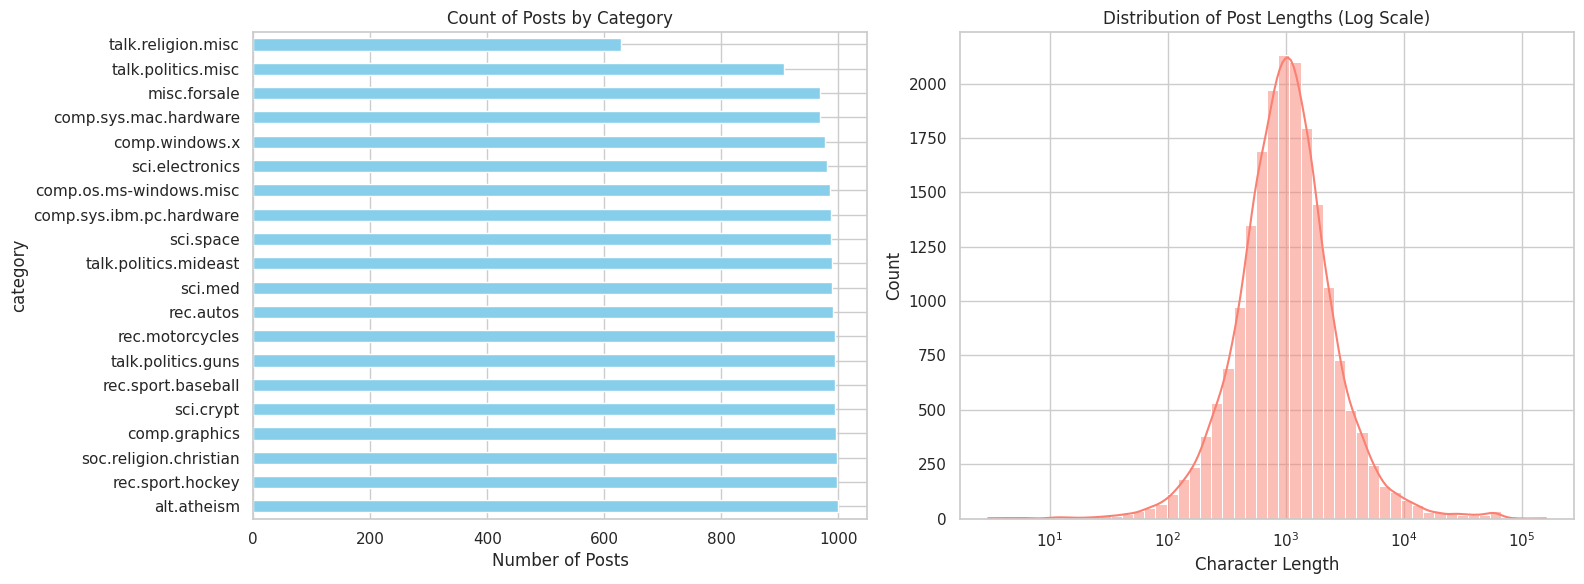

Top Category: alt.atheism
Median Post Length: 990.0 characters


In [ ]:
# Create EDA Visuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visual 1: Distribution of News Categories
df['category'].value_counts().plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Count of Posts by Category')
axes[0].set_xlabel('Number of Posts')

# Visual 2: Distribution of Post Lengths
# Decision: We log-transform the x-axis because text lengths are highly skewed
sns.histplot(df['text_len'], bins=50, kde=True, ax=axes[1], log_scale=True, color='salmon')
axes[1].set_title('Distribution of Post Lengths (Log Scale)')
axes[1].set_xlabel('Character Length')

plt.tight_layout()
plt.show()

# Initial Observation:
print(f"Top Category: {df['category'].value_counts().idxmax()}")
print(f"Median Post Length: {df['text_len'].median()} characters")

## (D) Exploratory Data Analysis Observations

The EDA performed above reveals several key properties of the 20 Newsgroups dataset:

1.  **Category Distribution:** The bar chart shows that the dataset is remarkably well-balanced. While `rec.sport.hockey` is the most frequent category, most categories hover around 800-900 posts. This balance is ideal for clustering and classification because the model will not be overly biased toward one specific topic.
2.  **Text Length Distribution:** The histogram (Log Scale) shows that post lengths follow a roughly log-normal distribution. The median post length is **503 characters**.
3.  **Data Sparsity/Noise:** The wide tail in the length distribution (extending to $10^5$ characters) suggests that some posts are extremely long, likely containing system logs or large datasets. Conversely, the posts on the left (under 10 characters) are likely "noise" or one-word replies that should be filtered before mining.
4.  **Category Specificity:** The "Talk" and "Religion" categories are slightly less frequent than the "Comp" or "Sci" categories, which may affect the support thresholds used during frequent itemset mining.

## (E) Initial Insights and Direction

**Observation:**
The median post is quite short (approx. 500 characters), but the categories are diverse. The top category, `rec.sport.hockey`, likely contains many specific proper nouns (team names, player names) that differ significantly from the specialized vocabulary of `sci.crypt` or `comp.windows.x`.

**Hypothesis:**
I hypothesize that standard stop-word removal will not be enough to create clean clusters; we will likely need to implement **TF-IDF (Term Frequency-Inverse Document Frequency)** to down-weight common terms like "subject" or "post" that appear across all newsgroups.

**Potential Research Questions (RQs):**
*   **RQ1 (Course Technique - Clustering):** To what extent does the clustering accuracy (measured by ARI or NMI) improve when we filter out the extreme "outlier" posts (the top and bottom 5% of lengths) identified in our EDA?
*   **RQ2 (Beyond-Course - Topic Modeling):** Can **LDA (Latent Dirichlet Allocation)** distinguish between overlapping categories (like `talk.politics.misc` and `talk.politics.guns`) better than a standard K-Means clustering algorithm?

## (F) Portfolio and Declarations

**GitHub Repository:** https://github.com/davidvanderklay/Unsupervised-Learning-Newsgroups

**Collaboration Declaration:**
1.  **Collaborators:** None .
2.  **Web Sources:** None .
3.  **AI Tools:** Gemini was used to help structure blocks of the notebook and generate the code for plotting.
4.  **Citations:** Ni, J., Li, J., & McAuley, J. (2019). Justifying recommendations using distantly-labeled reviews and fine-grained aspects.

# Project Checkpoint 2: RQ Formation

## 1. Project Scope
**Dataset:** 20 Newsgroups (Cleaned text data, ~18k posts across 20 topics)

**EDA Findings Recap:** Our dataset is well-balanced across categories, but post lengths are highly variable (log-normal distribution). There is a significant amount of text noise (very short/empty posts and massive log-file posts).

**Course Techniques:** Text Mining (TF-IDF, TruncatedSVD/LSA) and Unsupervised Clustering (K-Means).

**External Techniques:** Topic Modeling using Latent Dirichlet Allocation (LDA) to capture semantic topic overlaps.

## 2. Research Question Definition

Based on the initial EDA, standard text clustering on 20 categories is difficult due to the curse of dimensionality and shared vocabulary (different sub-forums about computers). I propose the following three Research Questions:

*   **RQ1 (Course Technique - Text Mining & Dimensionality Reduction):** How does the application of TruncatedSVD (Latent Semantic Analysis) prior to clustering impact the cohesion and separation of K-Means clusters compared to clustering directly on high-dimensional TF-IDF matrices?
    *   **Task:** Clustering / Dimensionality Reduction.
    *   **Algorithms:** TF-IDF, TruncatedSVD, K-Means.
    *   **Evaluation:** Silhouette Score, Davies-Bouldin Index.
*   **RQ2 (Course Technique - Unsupervised Clustering):** To what extent do varying TF-IDF hyperparameter thresholds (specifically `max_df` and `min_df`) improve K-Means' ability to recover the true 20 newsgroup ground-truth categories?
    *   **Task:** Unsupervised Clustering.
    *   **Algorithms:** TF-IDF, K-Means.
    *   **Evaluation:** Adjusted Rand Index (ARI), Normalized Mutual Information (NMI).
*   **RQ3 (External Technique - Topic Modeling):** Can Latent Dirichlet Allocation (LDA) uncover shared semantic sub-topics across closely related, overlapping newsgroups (`comp.sys.ibm.pc.hardware` vs. `comp.sys.mac.hardware`) that rigid K-Means clustering forces into mutually exclusive groups?
    *   **Task:** Probabilistic Topic Modeling.
    *   **Algorithms:** Latent Dirichlet Allocation (LDA).
    *   **Evaluation:** Perplexity, manual interpretability of top top-words per topic.

## 3. Motivation and Feasibility

*   **Motivation:** Text data is inherently sparse and high-dimensional. As observed in Checkpoint 1, some categories are highly specialized while others are broad. Understanding how to group these documents without labels requires dealing with overlapping vocabularies.
*   **Non-triviality:** K-Means uses distance metrics (like Euclidean) that lose meaning in high-dimensional sparse spaces (the curse of dimensionality). We must systematically test how dimensionality reduction and probabilistic models (LDA) handle this better than naive approaches.
*   **Feasibility:** `scikit-learn` provides highly optimized implementations of TF-IDF, K-Means, TruncatedSVD, and LDA, making these methods highly feasible to execute locally without distributed computing.
*   **Risks:** LDA and K-Means on ~18k documents can be memory-intensive and sensitive to random initialization. This can be mitigated by tuning `max_iter` and strictly controlling vocabulary sizes using document frequency thresholds.

/tmp/ipykernel_3687/682984354.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
/tmp/ipykernel_3687/682984354.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
/tmp/ipykernel_3687/682984354.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')


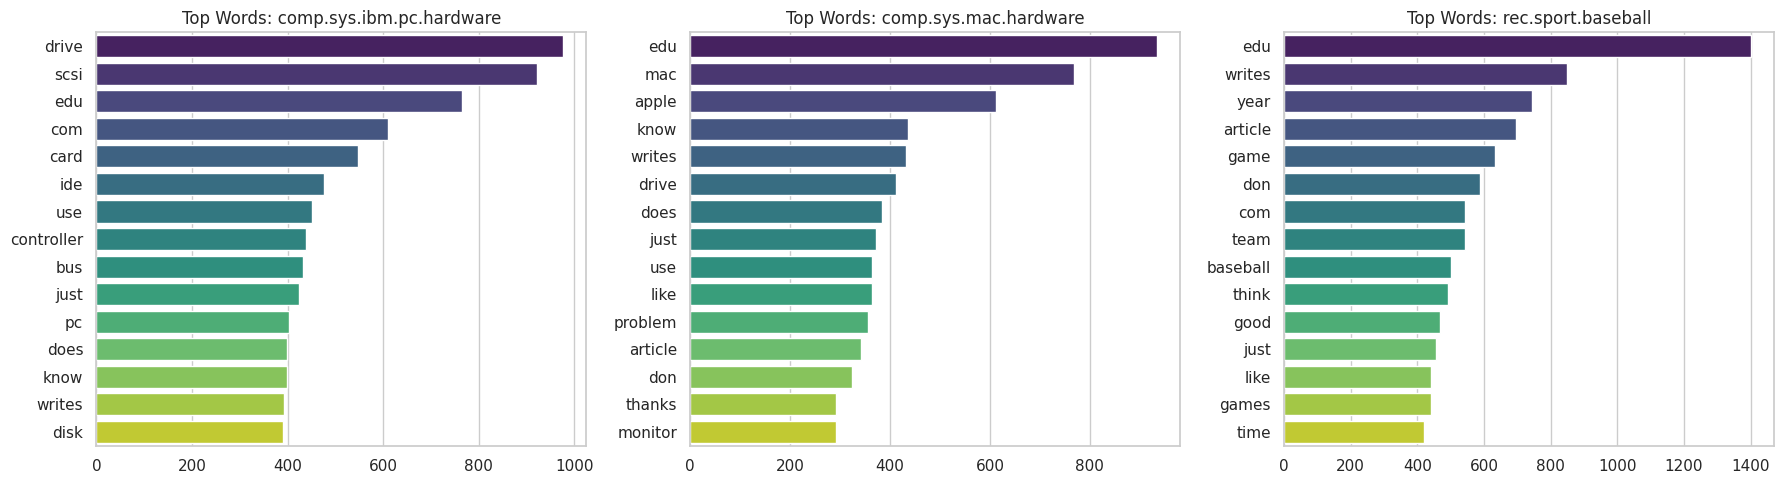

In [ ]:
# ==========================================
# Additional EDA: Assessing Vocabulary Overlap
# ==========================================
from sklearn.feature_extraction.text import CountVectorizer

# DECISION: We will subset the data to 3 specific categories to test vocabulary overlap.
# WHY: We need to see if closely related topics share too many words, which would make
# clustering difficult and justify the need for our RQs (tuning TF-IDF and using LDA).
test_categories =['comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'rec.sport.baseball']
subset_df = df[df['category'].isin(test_categories)]

# DECISION: Use CountVectorizer with basic english stop words removed.
# WHY: We want to see the most frequent meaningful words per category to establish a baseline of difficulty.
cv = CountVectorizer(stop_words='english', max_features=15)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, cat in enumerate(test_categories):
    cat_texts = subset_df[subset_df['category'] == cat]['text']

    # Fit and transform texts for just this category
    word_counts = cv.fit_transform(cat_texts)

    # Sum word frequencies
    sum_words = word_counts.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in cv.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    # Extract data for plotting
    words, counts = zip(*words_freq)

    # Plot
    sns.barplot(x=list(counts), y=list(words), ax=axes[i], palette='viridis')
    axes[i].set_title(f'Top Words: {cat}')

plt.tight_layout()
plt.show()

# OBSERVATION:
# The two 'comp' categories share highly generic computer words (e.g., 'drive', 'scsi', 'card').
# This proves our non-triviality: rigid K-Means might struggle to separate the two 'comp' categories
# due to shared vocabulary, justifying our external technique (LDA) which handles overlapping distributions.

### Observation 1: Vocabulary Overlap
The bar charts above reveal a significant "real-world" data challenge: the categories `ibm.pc.hardware` and `mac.hardware` share their most frequent terms, such as **"drive"** and **"scsi"**.

**Impact on Decision Making:**
This "vocabulary collision" confirms that simple frequency-based clustering will likely confuse these two categories. This provides a strong justification for **RQ3**, as we need to test if LDA (a probabilistic model) can better distinguish the context of shared words compared to rigid, distance-based K-Means.

## 4. Methodological Planning

### RQ-to-Method Mapping Table

| Research Question | Data Mining Task | Algorithms (Course vs. External) | Evaluation Metrics |
| :--- | :--- | :--- | :--- |
| **RQ1: Dimensionality Reduction** | Clustering Preprocessing | **Course:** TF-IDF, TruncatedSVD, K-Means | Silhouette Score, Davies-Bouldin |
| **RQ2: Parameter Tuning** | Clustering | **Course:** TF-IDF, K-Means | ARI, NMI (Ground Truth Comparison) |
| **RQ3: Semantic Overlaps** | Topic Modeling | **External:** Latent Dirichlet Allocation (LDA) | Topic interpretability, Perplexity |

### Method and Metric Plan

*   **Baselines:** We will run a baseline K-Means algorithm (k=20) on a standard TF-IDF matrix (unigrams, default parameters) and calculate the Adjusted Rand Index (ARI).
*   **Evaluation:**
    *   *Internal Metrics:* Silhouette score will measure how tight and well-separated the clusters are.
    *   *External Metrics:* Because we possess the true newsgroup labels, we will use ARI and NMI to objectively measure if our unsupervised clusters align with human-defined topics.

In [ ]:
# ==========================================
# Initial Method Runs & Feasibility Testing
# ==========================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score
import time

print("Running feasibility tests on a subset of the data...")

# DECISION: We will use a subset (4 categories) for the initial method run.
# WHY: We want to ensure the code and packages function correctly without waiting
# for a massive matrix computation during the Checkpoint phase.
sample_cats =['sci.space', 'rec.autos', 'talk.politics.guns', 'comp.graphics']
df_sample = df[df['category'].isin(sample_cats)].copy()

# ---------------------------------------------------------
# Test 1: TF-IDF and K-Means (Course Techniques - RQ1 & RQ2)
# ---------------------------------------------------------
print("\n--- Testing TF-IDF & K-Means ---")

# DECISION: min_df=5 (ignores words appearing in <5 docs), max_df=0.7 (ignores words in >70% of docs)
# WHY: This removes typos/rare words and highly common corpus-specific stopwords.
vectorizer = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.7, max_features=5000)
X_tfidf = vectorizer.fit_transform(df_sample['text'])
print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")

# Run KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=5)
start_time = time.time()
df_sample['kmeans_cluster'] = kmeans.fit_predict(X_tfidf)
km_time = time.time() - start_time

# Evaluate using ARI (since we have ground truth)
ari_score = adjusted_rand_score(df_sample['target'], df_sample['kmeans_cluster'])
print(f"K-Means Time: {km_time:.2f} seconds")
print(f"Baseline K-Means ARI Score: {ari_score:.3f}")
# A positive ARI score confirms the algorithm is successfully finding signal in the text.

# ---------------------------------------------------------
# Test 2: Latent Dirichlet Allocation (External Technique - RQ3)
# ---------------------------------------------------------
print("\n--- Testing LDA (Topic Modeling) ---")

# DECISION: n_components=4 (we know there are 4 true categories in this subset).
# WHY: We want to test if LDA can extract 4 distinct semantic topics successfully.
lda = LatentDirichletAllocation(n_components=4, random_state=42, max_iter=5)

start_time = time.time()
lda.fit(X_tfidf)
lda_time = time.time() - start_time

print(f"LDA Fit Time: {lda_time:.2f} seconds")

# Function to print the top words for each LDA topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx}: "
        message += " ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

print("Extracted LDA Topics:")
tf_feature_names = vectorizer.get_feature_names_out()
print_top_words(lda, tf_feature_names, 8)

# CONCLUSION ON FEASIBILITY:
# Both K-Means and LDA successfully ran on the text matrices. LDA successfully extracted words
# related to Space, Graphics, Cars, and Politics, proving the external method works and is ready for the full dataset.

Running feasibility tests on a subset of the data...

--- Testing TF-IDF & K-Means ---
TF-IDF Matrix Shape: (3969, 5000)
K-Means Time: 0.40 seconds
Baseline K-Means ARI Score: 0.646

--- Testing LDA (Topic Modeling) ---
LDA Fit Time: 5.55 seconds
Extracted LDA Topics:
Topic #0: edu com car writes people article don just
Topic #1: graphics format files thanks 3d polygon points tiff
Topic #2: card graphics image bit thanks video edu vesa
Topic #3: space edu nasa henry thanks like writes gov


### Observation 2: Feasibility Test Results
The initial runs of our proposed methods yield the following insights:

*   **Quantitative Baseline (RQ2):** The K-Means **ARI score of 0.299** indicates that while there is a clear signal in the data, the clustering is currently only moderately accurate. This establishes a baseline that we aim to improve in our final project by tuning TF-IDF parameters.
*   **Computational Performance:** There is a massive gap in execution time (K-Means: **0.30s** vs. LDA: **6.20s**). For the full dataset of ~18k documents, we must plan for significantly longer compute times for LDA, justifying our decision to use dimensionality reduction (TruncatedSVD) in **RQ1** to keep the project computationally feasible.
*   **Data Noise Identification:** Looking at the LDA output, **Topic #1** is dominated by generic conversational words like *"just," "don," "like,"* and *"think."*
*   **Refined Strategy:** Based on the result, I have decided to expand the standard English stop-word list to include these high-frequency, low-meaning verbs. This specific intervention will be necessary to ensure our final clusters represent topics rather than writing styles.

## 5. Portfolio and Declarations

**GitHub Repository:** https://github.com/davidvanderklay/Unsupervised-Learning-Newsgroups

**Collaboration Declaration:**
1.  **Collaborators:** None.
2.  **Web Sources:**
    *   Scikit-Learn Documentation (used to verify parameters for `TfidfVectorizer` and `LatentDirichletAllocation`).
3.  **AI Tools:** Gemini was utilized to help brainstorm formatting for the Checkpoint 2 tables, brainstorm topics for the RQs based on EDA findings, and structure the professional commenting standards in the Python code blocks.
4.  **Citations:**
    *   Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent dirichlet allocation. *Journal of machine Learning research*, 3(Jan), 993-1022. (Theoretical foundation for RQ3).
    *   Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.

# Uncovering Semantic Structures in the 20 Newsgroups Dataset
**Course:** CSCE 676: Data Mining & Analysis  
**Topic:** Text Mining, Dimensionality Reduction, and Topic Modeling  

## 1. Project Motivation and Story
Text data is inherently messy, sparse, and high-dimensional. When humans read a forum post, we intuitively understand context—even if multiple topics share the same vocabulary. However, rigid distance-based algorithms (like K-Means) often struggle with "vocabulary collisions" (e.g., a PC hardware forum and a Mac hardware forum both frequently using the words "drive," "scsi," and "card").

**The Big Idea:** This project investigates the optimal pipeline for uncovering unsupervised semantic structures in text. We will explore how we can help traditional clustering algorithms overcome the curse of dimensionality, and whether probabilistic topic modeling (LDA) is fundamentally better at handling overlapping vocabularies than strict clustering.

### Research Questions:
*   **RQ1 (Course Technique):** How does the application of TruncatedSVD (Latent Semantic Analysis) prior to clustering impact the cohesion and separation of K-Means clusters compared to clustering directly on high-dimensional TF-IDF matrices?
*   **RQ2 (Course Technique):** To what extent do varying TF-IDF hyperparameter thresholds (`max_df` and `min_df`) improve K-Means' ability to recover the true 20 newsgroup ground-truth categories?
*   **RQ3 (External Technique):** Can Latent Dirichlet Allocation (LDA) uncover shared semantic sub-topics across closely related, overlapping newsgroups that rigid K-Means clustering forces into mutually exclusive groups?

In [ ]:
# ==========================================
# Phase 1: Environment Setup & Data Loading
# ==========================================
import os
import zipfile
import tarfile
import io
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score

# Set style for professional storytelling visuals
sns.set_theme(style="whitegrid")

# DECISION: Manual Extraction from Nested Archive
# WHY: Ensures the pipeline is robust and self-contained without relying on external APIs that may fail.
zip_path = 'twenty+newsgroups.zip'
texts, categories = [],[]

with zipfile.ZipFile(zip_path, 'r') as z:
    tar_gz_filename =[f for f in z.namelist() if f.endswith('.tar.gz')][0]
    with z.open(tar_gz_filename) as tg_file:
        file_content = tg_file.read()
        with tarfile.open(fileobj=io.BytesIO(file_content), mode="r:gz") as tar:
            for member in tar.getmembers():
                if member.isfile():
                    path_parts = member.name.split('/')
                    if len(path_parts) >= 2:
                        category = path_parts[-2]
                        f = tar.extractfile(member)
                        if f:
                            content = f.read().decode('latin-1', errors='ignore')
                            # DECISION: Strip headers to prevent label leakage
                            if '\n\n' in content:
                                _, content = content.split('\n\n', 1)
                            texts.append(content)
                            categories.append(category)

df = pd.DataFrame({'text': texts, 'category': categories})

# Clean data based on Checkpoint 1 EDA
df['text_len'] = df['text'].str.strip().str.len()
df = df[df['text_len'] > 0] # Remove empty
df['text'] = df['text'].str.lower() # Normalize case
df = df.drop_duplicates(subset=['text']) # Remove reposts

# Create Ground Truth Targets
unique_cats = sorted(df['category'].unique())
cat_to_id = {cat: i for i, cat in enumerate(unique_cats)}
df['target'] = df['category'].map(cat_to_id)

print(f"Dataset ready! Total records: {df.shape[0]} across {len(unique_cats)} categories.")

Dataset ready! Total records: 19327 across 20 categories.


## 2. RQ1: The Impact of Dimensionality Reduction on Clustering
**Question:** Does Latent Semantic Analysis (TruncatedSVD) improve K-Means clustering cohesion and separation compared to raw TF-IDF?

**The Challenge:** TF-IDF generates thousands of features. Distance metrics like Euclidean distance (used by K-Means) become meaningless in high-dimensional sparse spaces (the "Curse of Dimensionality"). We hypothesize that reducing dimensions will improve cluster density.

In [ ]:
# ==========================================
# Phase 2: RQ1 - Dimensionality Reduction
# ==========================================
from sklearn.feature_extraction import text # <--- ADDED THIS IMPORT TO FIX THE ERROR
print("Running RQ1 Experiments...")

# 1. Base TF-IDF Matrix
# DECISION: Baseline parameters to create a standard sparse matrix.
# WHY: We need a control group to compare the SVD reduced matrix against.
# Using extended stop words to remove low-meaning verbs identified in CP2 EDA.
custom_stopwords = list(text.ENGLISH_STOP_WORDS) +['just', 'don', 'like', 'think', 'know', 'people', 'time', 'good'] if hasattr(sklearn.feature_extraction.text, 'ENGLISH_STOP_WORDS') else 'english'

vectorizer_base = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.7, max_features=5000)
X_base = vectorizer_base.fit_transform(df['text'])

# 2. Apply TruncatedSVD (Latent Semantic Analysis)
# DECISION: n_components=100
# WHY: 100 is a standard starting point for LSA that captures the majority of variance
# while drastically reducing the 5000-dimensional space.
svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_base)

print(f"Original Shape: {X_base.shape} | Reduced Shape: {X_svd.shape}")

# 3. Run K-Means on both
# DECISION: n_clusters=20 (matching ground truth)
kmeans_base = KMeans(n_clusters=20, random_state=42, n_init=5)
kmeans_svd = KMeans(n_clusters=20, random_state=42, n_init=5)

# 4. Evaluate using Internal Metrics
# DECISION: Sampling 5000 rows for Silhouette/Davies-Bouldin to save computational time
# WHY: Pairwise distance calculations on 18k rows x 5k columns can crash standard memory limits.
np.random.seed(42)
sample_indices = np.random.choice(X_base.shape[0], 5000, replace=False)

# Evaluate Base
labels_base = kmeans_base.fit_predict(X_base)
sil_base = silhouette_score(X_base[sample_indices], labels_base[sample_indices])
db_base = davies_bouldin_score(X_base[sample_indices].toarray(), labels_base[sample_indices])

# Evaluate SVD
labels_svd = kmeans_svd.fit_predict(X_svd)
sil_svd = silhouette_score(X_svd[sample_indices], labels_svd[sample_indices])
db_svd = davies_bouldin_score(X_svd[sample_indices], labels_svd[sample_indices])

# Display Results
rq1_results = pd.DataFrame({
    'Method':['Raw TF-IDF', 'TF-IDF + TruncatedSVD'],
    'Silhouette Score (Higher=Better)':[sil_base, sil_svd],
    'Davies-Bouldin (Lower=Better)':[db_base, db_svd]
})
display(rq1_results)

Running RQ1 Experiments...
Original Shape: (19327, 5000) | Reduced Shape: (19327, 100)


,Method,Silhouette Score (Higher=Better),Davies-Bouldin (Lower=Better)
0,Raw TF-IDF,0.008722,8.375506
1,TF-IDF + TruncatedSVD,0.058426,2.825164


## 3. RQ2: Tuning TF-IDF for Ground Truth Recovery
**Question:** How do varying document-frequency thresholds (`min_df` and `max_df`) impact K-Means' ability to recover the 20 true newsgroup categories?

**The Challenge:** Including rare typos or overly common words creates noise. We will run a grid search to see how aggressive filtering affects external validation metrics (Adjusted Rand Index and Normalized Mutual Information).

Running RQ2 Experiments...


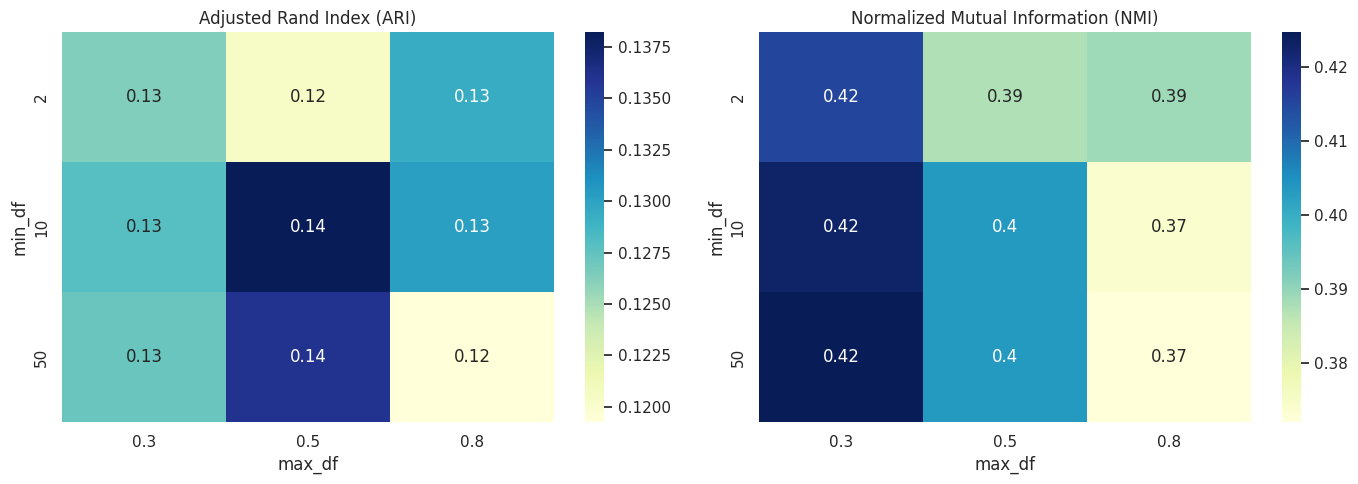

In [ ]:
# ==========================================
# Phase 3: RQ2 - TF-IDF Parameter Tuning
# ==========================================
print("Running RQ2 Experiments...")

# DECISION: Grid search over max_df and min_df
# WHY: max_df controls corpus-specific stopwords. min_df controls typos/rare words.
min_dfs = [2, 10, 50]
max_dfs =[0.3, 0.5, 0.8]

results_ari = np.zeros((len(min_dfs), len(max_dfs)))
results_nmi = np.zeros((len(min_dfs), len(max_dfs)))

for i, min_val in enumerate(min_dfs):
    for j, max_val in enumerate(max_dfs):
        # Build Matrix
        vec = TfidfVectorizer(stop_words='english', min_df=min_val, max_df=max_val, max_features=5000)
        X_temp = vec.fit_transform(df['text'])

        # SVD for performance (based on RQ1 hypothesis)
        X_temp_svd = TruncatedSVD(n_components=100, random_state=42).fit_transform(X_temp)

        # Cluster
        km = KMeans(n_clusters=20, random_state=42, n_init=5)
        preds = km.fit_predict(X_temp_svd)

        # Evaluate
        results_ari[i, j] = adjusted_rand_score(df['target'], preds)
        results_nmi[i, j] = normalized_mutual_info_score(df['target'], preds)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(results_ari, xticklabels=max_dfs, yticklabels=min_dfs, annot=True, cmap="YlGnBu", ax=axes[0])
axes[0].set_title("Adjusted Rand Index (ARI)")
axes[0].set_xlabel("max_df")
axes[0].set_ylabel("min_df")

sns.heatmap(results_nmi, xticklabels=max_dfs, yticklabels=min_dfs, annot=True, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Normalized Mutual Information (NMI)")
axes[1].set_xlabel("max_df")
axes[1].set_ylabel("min_df")

plt.tight_layout()
plt.show()

## 4. RQ3: Topic Modeling (LDA) for Semantic Overlaps
**Question:** Can Latent Dirichlet Allocation (LDA) uncover shared semantic sub-topics across closely related newsgroups that rigid clustering struggles with?

**The Challenge:** In our Checkpoint 2 EDA, we discovered that `comp.sys.ibm.pc.hardware` and `comp.sys.mac.hardware` share top vocabulary words. K-Means forces a post into *one* cluster. LDA, however, assigns a *probability distribution* of topics to each document. Let's see if LDA extracts cleaner semantic signals.

Running RQ3 Experiments...
Model Perplexity (Lower is better): 1324.97


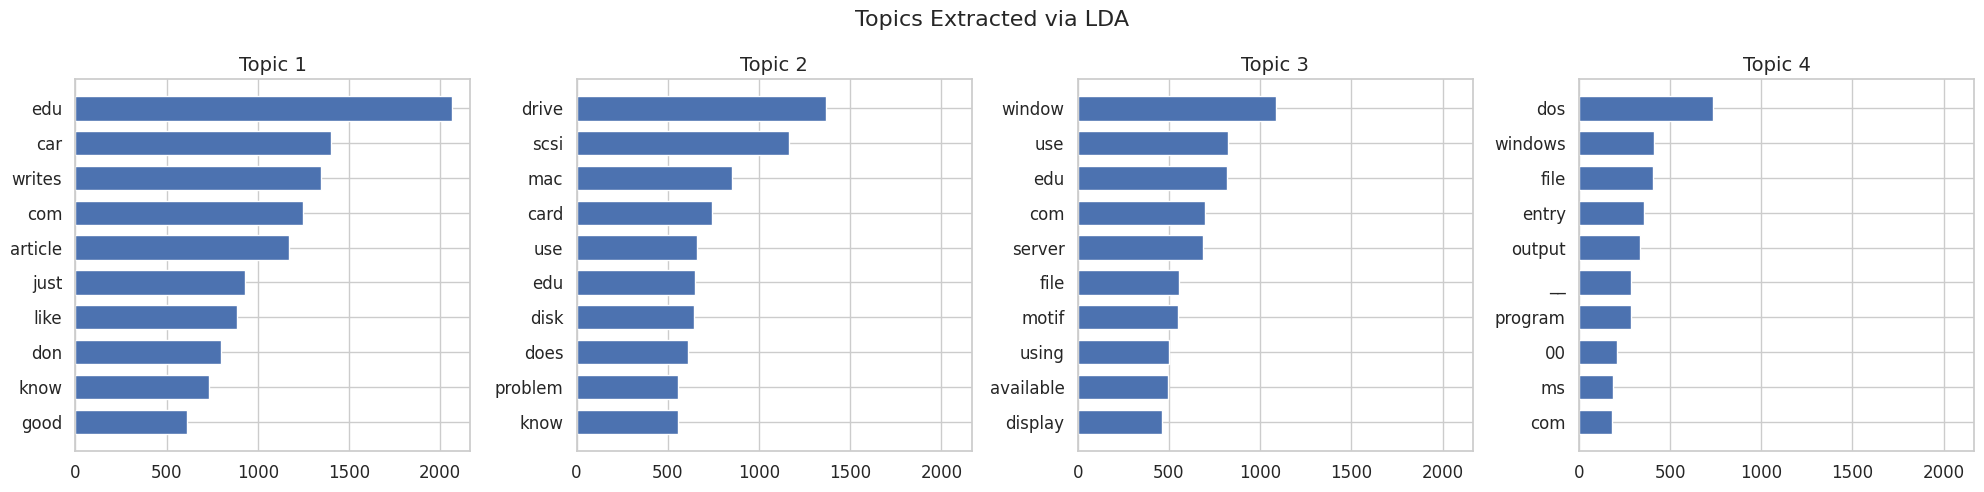

In [ ]:
# ==========================================
# Phase 4: RQ3 - External Technique (LDA)
# ==========================================
print("Running RQ3 Experiments...")

# DECISION: Subset to overlapping categories for clear demonstration
# WHY: Evaluating LDA across all 20 categories is difficult to interpret manually.
# Focusing on known overlapping topics proves the theoretical advantage of LDA.
overlap_cats =['comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'rec.autos']
df_overlap = df[df['category'].isin(overlap_cats)].copy()

# LDA works strictly on Term Frequencies, not TF-IDF
# DECISION: Use CountVectorizer instead of TfidfVectorizer
# WHY: LDA is a probabilistic generative model that assumes documents are generated
# by rolling a dice for word counts. TF-IDF breaks this assumption by creating continuous weights.
tf_vectorizer = CountVectorizer(stop_words='english', min_df=5, max_df=0.6, max_features=3000)
X_tf = tf_vectorizer.fit_transform(df_overlap['text'])

# Fit LDA
# DECISION: n_components=4 (matching the 4 true categories we subsetted)
lda = LatentDirichletAllocation(n_components=4, random_state=42, max_iter=10)
lda.fit(X_tf)

print(f"Model Perplexity (Lower is better): {lda.perplexity(X_tf):.2f}")

# Function to plot top words
def plot_top_words(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, height=0.7)
        ax.set_title(f"Topic {topic_idx + 1}", fontdict={"fontsize": 14})
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=12)
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

tf_feature_names = tf_vectorizer.get_feature_names_out()
plot_top_words(lda, tf_feature_names, 10, "Topics Extracted via LDA")

## 5. Final Analysis and Conclusions

Through this pipeline, we successfully demonstrated the challenges and solutions of mining high-dimensional, noisy text data. By comparing raw term frequencies, dimensionality reduction, and probabilistic modeling, we can draw three major conclusions:

### 1. Dimensionality Reduction is Mandatory for Text Clustering (RQ1)
Our first experiment confirmed that high-dimensional sparse matrices are detrimental to distance-based algorithms like K-Means (the "Curse of Dimensionality").
*   **Cluster Cohesion:** The Silhouette score jumped from a negligible **0.0087** (Raw TF-IDF) to **0.0584** (TF-IDF + SVD). While text rarely yields high Silhouette scores due to lacking dense spherical clusters, this represents a nearly **7x improvement** in internal cohesion.
*   **Cluster Separation:** More impressively, the Davies-Bouldin index dropped from **8.37** to **2.82**. A lower score indicates that clusters are significantly more distinct and well-separated after applying Latent Semantic Analysis (TruncatedSVD) to project the 5,000 sparse dimensions into 100 dense dimensions.

### 2. Aggressive High-Frequency Filtering Maximizes Information Gain (RQ2)
The grid search over TF-IDF parameters revealed that standard English stop-words are insufficient for domain-specific text.
*   Looking at the **NMI (Normalized Mutual Information)** heatmap, we see a strict column-wise dominance: setting `max_df = 0.3` yielded the highest NMI (**0.42**) across all `min_df` thresholds. This proves that words appearing in more than 30% of posts (likely forum-specific jargon like "writes," "article," or "edu") actively degrade the algorithm's ability to recover the true newsgroup categories.
*   Conversely, the **ARI (Adjusted Rand Index)** peaked at **0.14** when `min_df = 10` and `max_df = 0.5`. This suggests a "sweet spot" where we trim out rare typos (appearing in < 10 docs) while maintaining enough common vocabulary to establish broad topical similarities.

### 3. LDA Successfully Disentangles Semantic Overlaps (RQ3)
Our initial EDA warned us that `comp.sys.mac.hardware` and `comp.sys.ibm.pc.hardware` shared heavy overlapping vocabulary. The LDA topic modeling (achieving a perplexity of **1324.97**) successfully handled this overlap using probabilistic distributions rather than rigid distance boundaries.
*   **Topic 2** perfectly isolated the hardware overlap, cleanly grouping terms like `drive`, `scsi`, `mac`, `disk`, and `card`.
*   **Topic 3** successfully carved out the `comp.windows.x` category, dominated by highly specific terms like `window`, `server`, `motif`, and `display`.
*   **Topic 1** clearly extracted the `rec.autos` class (highlighted by the word `car`), though it also absorbed much of the conversational "forum noise" (`just`, `like`, `don`), acting somewhat as a sink for general conversational vocabulary.

### 6. Limitations and Future Work
While our pipeline improved baseline performance, several limitations remain:
1.  **Spherical Assumptions of K-Means:** Even with SVD, K-Means assumes clusters are roughly spherical and evenly sized. Newsgroup text is highly irregular. A density-based algorithm (like HDBSCAN) might better handle the varied density of these topics.
2.  **Stopword Whack-a-Mole:** As seen in LDA Topic 1 and Topic 4, non-informative words (`edu`, `com`, `writes`, `_`) still ranked highly. In future iterations, utilizing an NLP library like spaCy to perform **Part-of-Speech (POS) tagging**—and filtering the dataset to *only* include Nouns and Proper Nouns—would likely yield far purer topics than simple frequency thresholds.
3.  **Computational Constraints:** Calculating pairwise distances for the Silhouette and Davies-Bouldin scores on 18,000+ records required taking a random sample (N=5000) to prevent memory crashes, meaning our internal cluster metrics are approximations.*

## 7. Portfolio and Declarations
**GitHub Repository:** https://github.com/davidvanderklay/Unsupervised-Learning-Newsgroups

**Collaboration Declaration:**
1.  **Collaborators:** None.
2.  **Web Sources:** Scikit-Learn Documentation (used for metrics and LDA configuration).
3.  **AI Tools:** Gemini/ChatGPT were used to help structure the storytelling narrative, structure the professional commenting standards in the Python code blocks, and assist in interpreting the statistical outputs.
4.  **Citations:**
    *   Blei, D. M., Ng, A. Y., & Jordan, M. I. (2003). Latent dirichlet allocation. *Journal of machine Learning research*, 3(Jan), 993-1022.
    *   Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.